## **HEALTH INSURANCE PRICE PREDICTION**

**PROBLEM STATEMENT**

The goal of this project is to develop a **predictive model** that accurately estimates the **medical insurance costs** for individuals based on various **demographic, lifestyle, and health-related factors.** By applying **machine learning techniques,** we aim to assist **insurance companies** in better understanding their risk profiles and help **individuals gain insights** into how different factors influence their **insurance premiums.**

**Import the libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Load data**

In [ ]:
data = pd.read_csv('/content/insurance.csv')

In [ ]:
#check number of rows and columns
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


**Domain Analysis** The descriptions of the variables based on the insurance dataset:

1.**Age**
  - **Description:** Age of the primary beneficiary covered by health insurance.
  - **Type:** Continuous numerical variable.

2.**Sex**
  - **Description:** Gender of the insurance contractor.
  - **Type:** Categorical variable with two levels: female, male.

3.**BMI (Body Mass Index)**
  - **Description:** Body mass index, which is a measure of body fat based on height and weight.
  - **Type:** Continuous numerical variable.
  - **Ideal Range:** Ideally between 18.5 to 24.9 kg/m².

4.**Children**
  - **Description:** Number of children covered by health insurance or number of dependents.
  - **Type:** Discrete numerical variable.

5.**Smoker**
  - **Description:** Binary indicator if the beneficiary is a smoker.
  - **Type:** Categorical variable with two levels: yes, no.

6.**Region**
  - **Description:** The beneficiary's residential area in the US.
  - **Type:** Categorical variable with four levels: northeast, southeast, southwest, northwest.

7.**Charges**
  - **Description:** Individual medical costs billed by health insurance.
  - **Type:** Continuous numerical variable.




In [ ]:
#check number of rows and columns
data.shape

(1338, 7)

The dataset has 1338 rows and 7 columns.


In [ ]:
#print first 5 rows
data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [ ]:
#print first 5 rows
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
#data info: memory usuage
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
#print all columns
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
#print numerical columns
num_cols = data.select_dtypes(include=['int64','float64'])
num_cols

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


In [ ]:
#print only chategorical columns
cat_cols = data.select_dtypes(include='object')
cat_cols

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest
...,...,...,...
1333,male,no,northwest
1334,female,no,northeast
1335,female,no,southeast
1336,female,no,southwest


In [ ]:
#check data type of each column
data.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
#find statistical report for numerical data
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
#find statistical report for categorical data
data.describe (include='object')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [ ]:
#find unique values
for x in cat_cols:
  print(x,'-->',data[x].unique())

sex --> ['female' 'male']
smoker --> ['yes' 'no']
region --> ['southwest' 'southeast' 'northwest' 'northeast']


In [ ]:
#find valuecount of each
for x in cat_cols:
  print(data[x].value_counts())
  print()

sex
male      676
female    662
Name: count, dtype: int64

smoker
no     1064
yes     274
Name: count, dtype: int64

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64



# **Data Cleaning**

**Check for missing values and hangle them**

In [ ]:
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


**Check for duplicates and if any duplicate just drop**

In [ ]:
data.duplicated().sum()

np.int64(1)

In [ ]:
#drop duplicates
data.drop_duplicates(inplace=True)

In [ ]:
data.duplicated().sum()

np.int64(0)

**Exploratory Data Analysis**

**Exploratory Data Analysis**

Analysis single variable/column
 * histogram
 * count plot
 * box plot

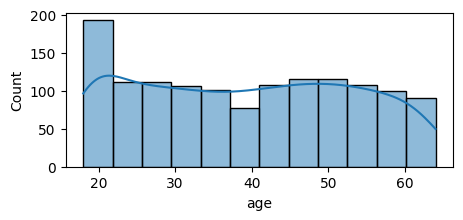

In [ ]:
#check the distribution of age
plt.figure(figsize=(5,2))
sns.histplot(data,x='age',kde=True)
plt.show()

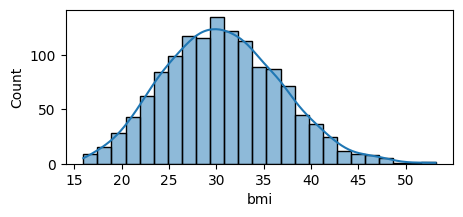

In [ ]:
#check the distribution of bmi
plt.figure(figsize=(5,2))
sns.histplot(data,x='bmi',kde=True)
plt.show()

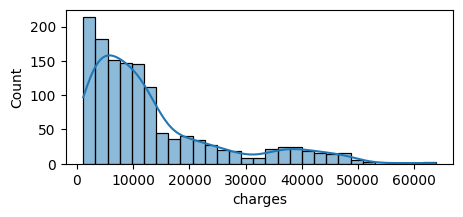

In [ ]:
#check the distribution of charges
plt.figure(figsize=(5,2))
sns.histplot(data,x='charges',kde=True)
plt.show()

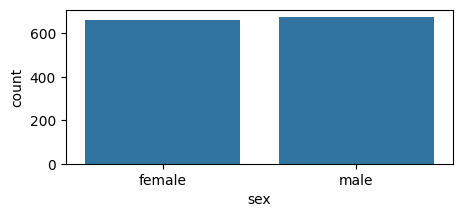

In [ ]:
#Visualise count of male and female
plt.figure(figsize=(5,2))
sns.countplot(data,x='sex')
plt.show()

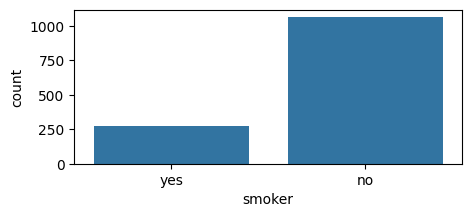

In [ ]:
#visualize count of smokers and non smoker
plt.figure(figsize=(5,2))
sns.countplot(data,x='smoker')
plt.show()

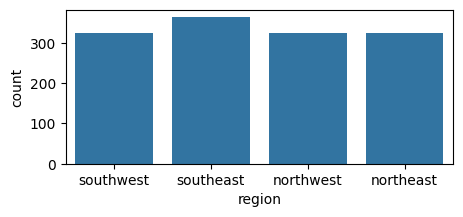

In [ ]:
#visualise count of region
plt.figure(figsize=(5,2))
sns.countplot(data,x='region')
plt.show()

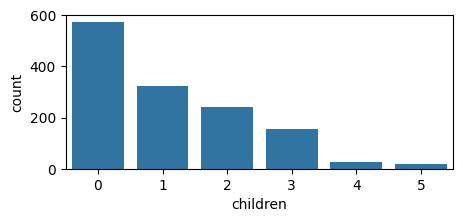

In [ ]:
#visualise count of children
plt.figure(figsize=(5,2))
sns.countplot(data,x='children')
plt.show()

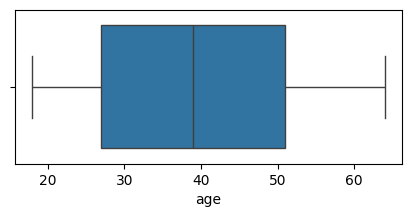

In [ ]:
#check outliers in age
plt.figure(figsize=(5,2))
sns.boxplot(data,x='age')
plt.show()

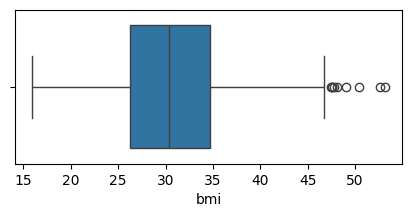

In [ ]:
#check the distribution
plt.figure(figsize=(5,2))
sns.boxplot(data,x='bmi')
plt.show()

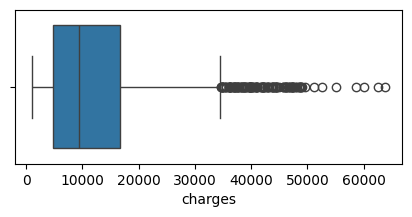

In [ ]:
#check outliers in charges
plt.figure(figsize=(5,2))
sns.boxplot(data,x='charges')
plt.show()

**Bivariate Analysis**
analysis two variables/columns
* scatter
* Line
* Bar plot

<Axes: xlabel='age', ylabel='charges'>

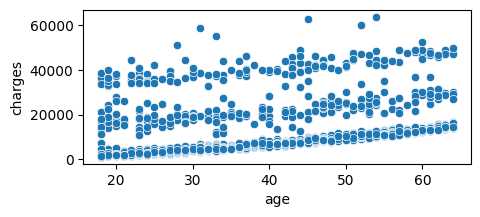

In [ ]:
#check the realtionship between age and charges
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='age',y='charges')

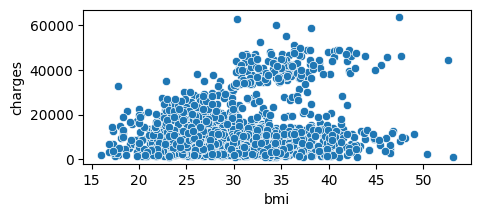

In [ ]:
#Check the realtionship between bmi and charges
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='bmi',y='charges')
plt.show()

<Axes: xlabel='sex', ylabel='charges'>

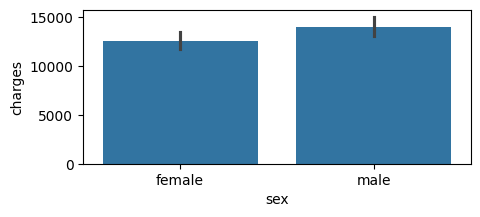

In [ ]:
#compare how charges vary with gender
plt.figure(figsize=(5,2))
sns.barplot(data,x='sex',y='charges')

<Axes: xlabel='smoker', ylabel='charges'>

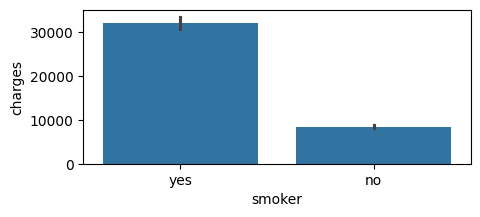

In [ ]:
#compare how charges vary with smoker
plt.figure(figsize=(5,2))
sns.barplot(data,x='smoker',y='charges')

<Axes: xlabel='region', ylabel='charges'>

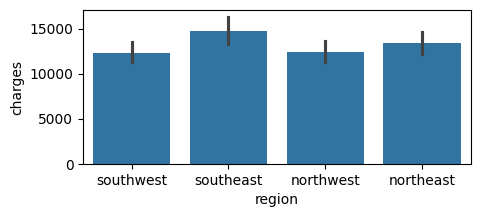

In [ ]:
#compare how charges vary with region
plt.figure(figsize=(5,2))
sns.barplot(data,x='region',y='charges')

<Axes: xlabel='children', ylabel='charges'>

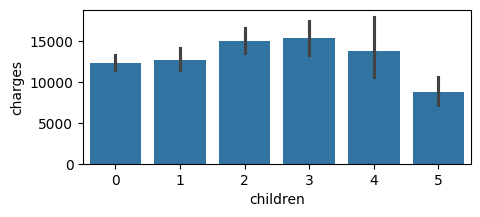

In [ ]:
#compare how charges vary with children
plt.figure(figsize=(5,2))
sns.barplot(data,x='children',y='charges')

**Multivated Analysis**

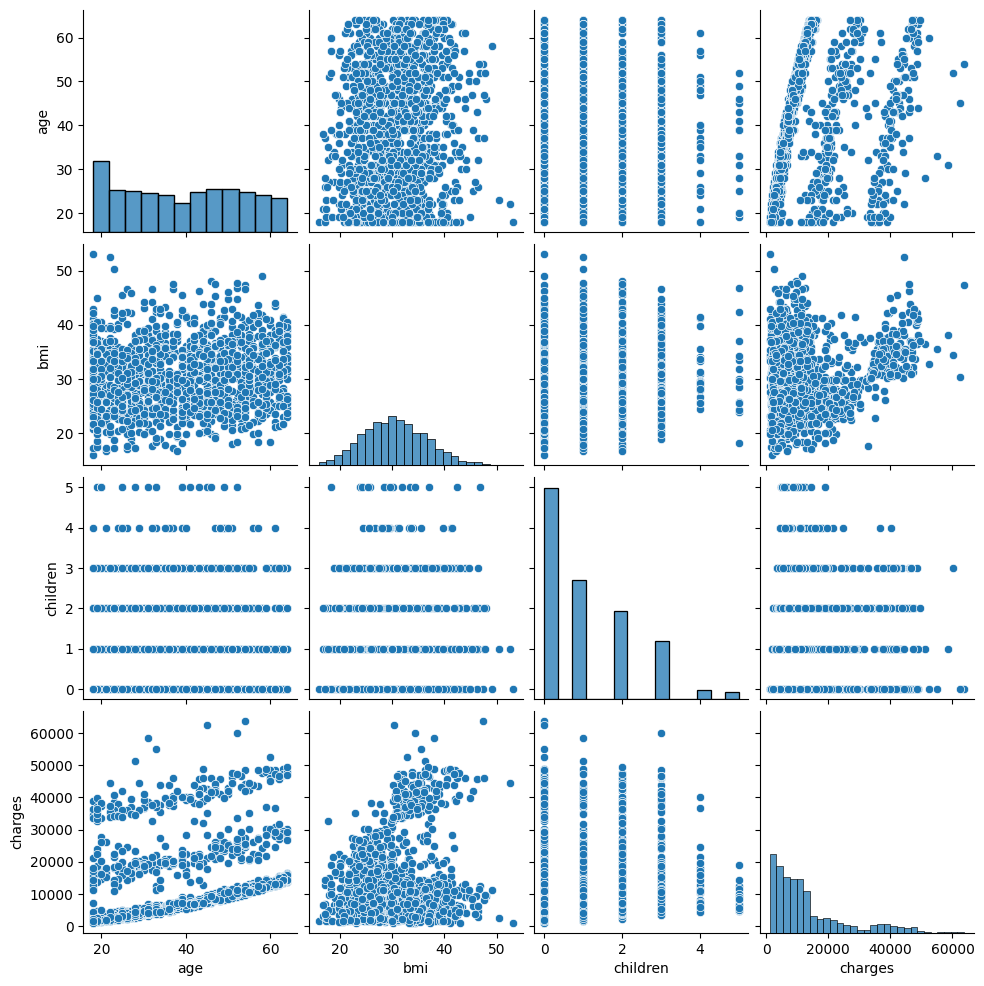

In [ ]:
# pairplot: It creates scatter plot among all the numerical variables
sns.pairplot(data)

In [ ]:
#heat map : Used to visualize the correlation
# Correlation measures how strong two variables
num_cols.corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


<Axes: >

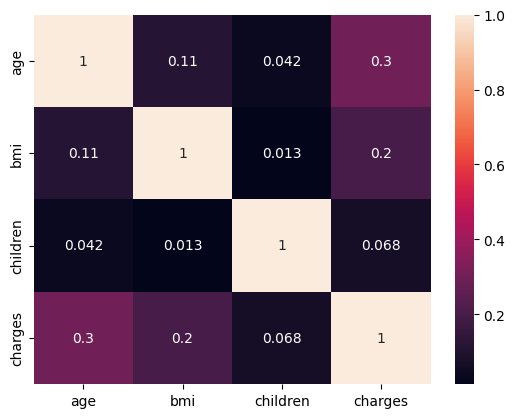

In [ ]:
sns.heatmap(num_cols.corr(),annot=True)

**Handle Outliers**

Outliers are extreme values which are far away from actual data or range.

Eg: Age of Student:[20,21,22,23,24,98,100]

In this 98 and 100 are outliers.

**Ways to Identify Outliers**
  * Box plot
  * Scatter plot
  * Histogram

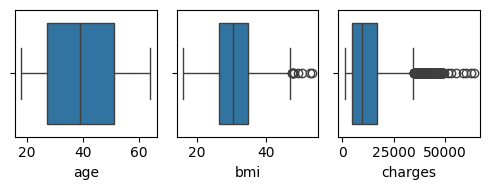

In [ ]:
fig,ax = plt.subplots(1,3,figsize=(5,2))
sns.boxplot(data,x='age',ax=ax[0])
sns.boxplot(data,x='bmi',ax=ax[1])
sns.boxplot(data,x='charges',ax=ax[2])
plt.tight_layout()

There are outliers in bmi and charges towards right side.

**Find Outliers**
   1. IQR(Inter quartile range): Used when data distribution is skewed.
   2. 3 sigma rule: Used when data is normal.
   3. Outliers should handled only if 1% of outliers are less than 5%.

**Check the distribution of bmi and charges**

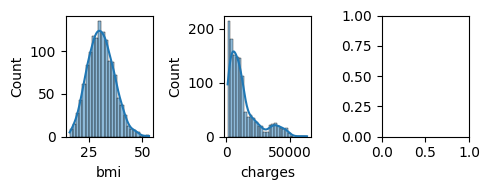

In [ ]:
fig,ax = plt.subplots(1,3,figsize=(5,2))
sns.histplot(data,x='bmi',ax=ax[0],kde=True)
sns.histplot(data,x='charges',ax=ax[1],kde=True)
plt.tight_layout()

In [ ]:
#find skew
data.loc[:,'bmi'].skew()

np.float64(0.28391419385321137)

In [ ]:
data.loc[:,'charges'].skew()

np.float64(1.5153909108403483)

- BMI data distributiom is normal.
- Charges distribution is right skewed.

**IQR method for Charges**

Data distribution is skewed

1. Find Q1
2. Find Q3
3. IQR
4. lower_limit = Q1-1.5*IQR
5. upper_limit = Q3+1.58IQR
6. If any value greater than upper limit or less then lower limit, we call them as outliers.

In [ ]:
Q1 = data.loc[:,'charges'].quantile(0.25)
Q3 = data.loc[:,'charges'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q1 - 1.5 * IQR

In [ ]:
#filter all the values greater than upper_limit
data[data.loc[:,'charges']>upper_limit]

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
#filter all the values greater than lower_limit
data[data.loc[:,'charges']>lower_limit]

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
#percentage of outliers
len(data[(data.loc[:,'charges']>upper_limit) | (data.loc[:,'charges']<lower_limit)])/len(data)*100

100.0

Since % of outliers are 10% which are more than 5% that means all these high charges are important. If age high obviously insurance charge will be high

If it was less than 5% we could have replace with median.

**3 Sigma rule for BMI**

Data distribution of bmi is normal

1. Find mean
2. find Standard deviation
3. lower limit = mean - 3* std
4. upper lim it = mean + 3* std
5. Any value greater then upper limit or less than lower is considered as oulier.

In [ ]:
mean_val = data.loc[:,'bmi'].mean()
std_val = data.loc[:,'bmi'].std()
lower_limit = mean_val - 3*std_val
upper_limit = mean_val + 3*std_val

In [ ]:
#filter values greater than upper limit
data[data.loc[:,'bmi']>upper_limit]

,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.3254
847,23,male,50.38,1,no,southeast,2438.0552
1047,22,male,52.58,1,yes,southeast,44501.3982
1317,18,male,53.13,0,no,southeast,1163.4627


In [ ]:
#filter values less than lower limit
data[data.loc[:,'bmi']<lower_limit]

,age,sex,bmi,children,smoker,region,charges


In [ ]:
#find %
len(data[(data.loc[:,'bmi']>upper_limit) | (data.loc[:,'bmi']<lower_limit)])/len(data)*100

0.2991772625280479

Since % of outliers is less than 5% we need to replace them with mean

In [ ]:
data.loc[data.loc[:,'bmi']>upper_limit,'bmi']=data.loc[:,'bmi'].mean()

In [ ]:
data[data.loc[:,'bmi']>upper_limit]

,age,sex,bmi,children,smoker,region,charges


**Encoding Technique**

The process of converting text to numerical so that machine can be understand

* Label Encoder
* One hot Encoder
* Ordinal Encoder
* Trader Encoder
* Manual Encoder

**Label Encoder**

Label Encoder assigns unique numbers to text starting from 0 according to alphabetical order.

In [ ]:
# Yes - 1
# No - 0

In [ ]:
# red - 2
# green - 1
# blue - 0

In [ ]:
# UG - 2
# PHD - 1
# PG - 0

# male - 1
# female - 0

# Label Encoder doesn't work when order matters or priority matters.
# Use label Encoder when order doesn't matter or no priority issues.

**Smoker**

Label Encoder

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data.loc[:,'smoker'] = le.fit_transform(data.loc[:,'smoker'])


In [ ]:
#drop old smoker column
data.drop(columns='smoker',inplace=True)

# One hot Encoding
Creates new columns according to categoris and assign 1 if value exixts else 0

In [ ]:
# Gender | male | female
# male   |   1  |   0
# female |   0  |   1
# male   |   1  |   0
# female |   0  |   1
# male   |   1  |   0

# used one hot when all categories should be treated equally
#avoid using when there are so many categories

In [ ]:
#sex
data=pd.get_dummies(data,columns=['sex'],dtype='int')
data

,age,bmi,children,region,charges,sex_female,sex_male
0,19,27.900,0,southwest,16884.92400,1,0
1,18,33.770,1,southeast,1725.55230,0,1
2,28,33.000,3,southeast,4449.46200,0,1
3,33,22.705,0,northwest,21984.47061,0,1
4,32,28.880,0,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...
1333,50,30.970,3,northwest,10600.54830,0,1
1334,18,31.920,0,northeast,2205.98080,1,0
1335,18,36.850,0,southeast,1629.83350,1,0
1336,21,25.800,0,southwest,2007.94500,1,0


# manual Encoder
Assign balues manually beased on priority

In [ ]:
# UG - 0
# PG - 1
# PHD - 2

# Original Encoder
Assign values based on order/ranking

In [ ]:
# High : 2
# Average : 1
# Low : 0

# Target Encoding
Assign values based on comparing column with target column.

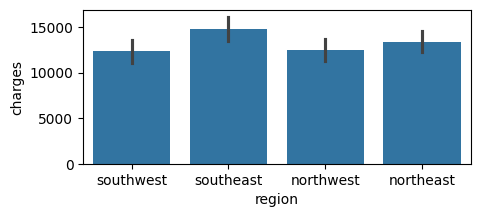

In [ ]:
# Region
plt.figure(figsize = (5,2))
sns.barplot(data,x='region',y='charges')
plt.show()

In [ ]:
data.loc[:,'Region']=data.loc[:,'region'].map({'southwest':0,'northwest':1,'northeast':2,'southeast':3})

In [ ]:
data.drop(columns='region',inplace=True)

#Scaling
If there is a huge variation among the values in different numerical column we using scaling to bring all the values to a same scale so that calculations becomes easy.

* Minmax scaler
* Standard scaler

#Minmax scaler
If transforms all the values into a range 0 to 1

In [ ]:
df = data.copy()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data[['age']]=scaler.fit_transform(data[['age']])
data[['bmi']]=scaler.fit_transform(data[['bmi']])

#Standard Scaler
It transforms all the values to same scale so that mean of column of column will be 0 and std will be 1.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['age']]=scaler.fit_transform(df[['age']])
df[['bmi']]=scaler.fit_transform(df[['bmi']])

# Log Transformation
- Usually applied on target column only in regression.
- It is used to transform skewed data into normal distribution.
- Linear regression ecxpects data distrbution of target to be normal.

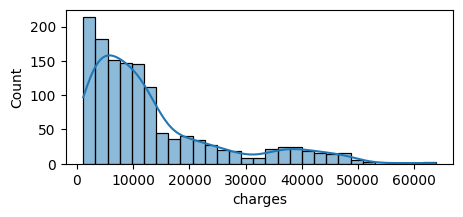

In [ ]:
# charges
plt.figure(figsize=(5,2))
sns.histplot(data,x='charges',kde=True)
plt.show()

In [ ]:
data.loc[:,'charges']=np.log(data.loc[:,'charges'])

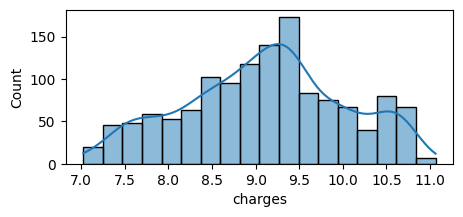

In [ ]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='charges',kde=True)
plt.show()

#Feature Engineering
* select best features
* Drop the columns
* Ctreate a new column

# Split data for x and y

In [ ]:
x = data.drop(columns='charges')
y = data['charges']

#Split data for training and testing

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.shape

(1069, 6)

In [ ]:
x_test.shape

(268, 6)

#Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
#train model with x_train, y_train
model.fit(x_train,y_train)
# make predictions using x_test
y_pred = model.predict(x_test)

In [ ]:
#slope
model.coef_

array([ 1.50249406,  0.26639588,  0.11045378, -0.01448084,  0.01448084,
        0.0417738 ])

In [ ]:
#intercept
model.intercept_

np.float64(8.094985178238629)

#Evaluate the Regression

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error

In [ ]:
#mean squared error
mean_squared_error(y_test,y_pred)

0.6211048714405922

In [ ]:
#mean absolute error
mean_absolute_error(y_test,y_pred)

0.6408769012085327

In [ ]:
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(0.7881020691766976)

In [ ]:
# mape
mean_absolute_percentage_error(y_test,y_pred)

0.06940336689993024

In [ ]:
# r2 score
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
r2

0.33083579346569547

In [ ]:
#adjusted r2_score
n = x_test.shape[0]
n # number of rows

268

In [ ]:
# p : no of columns
p = x_test.shape[1]
p

6

In [ ]:
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.3154527082580103